In [1]:
import os
import pathlib 
import pickle

import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio
from PIL import Image

import importlib
from courtvisionlib.functions import *
import project_config as config
importlib.reload(config)
%matplotlib inline

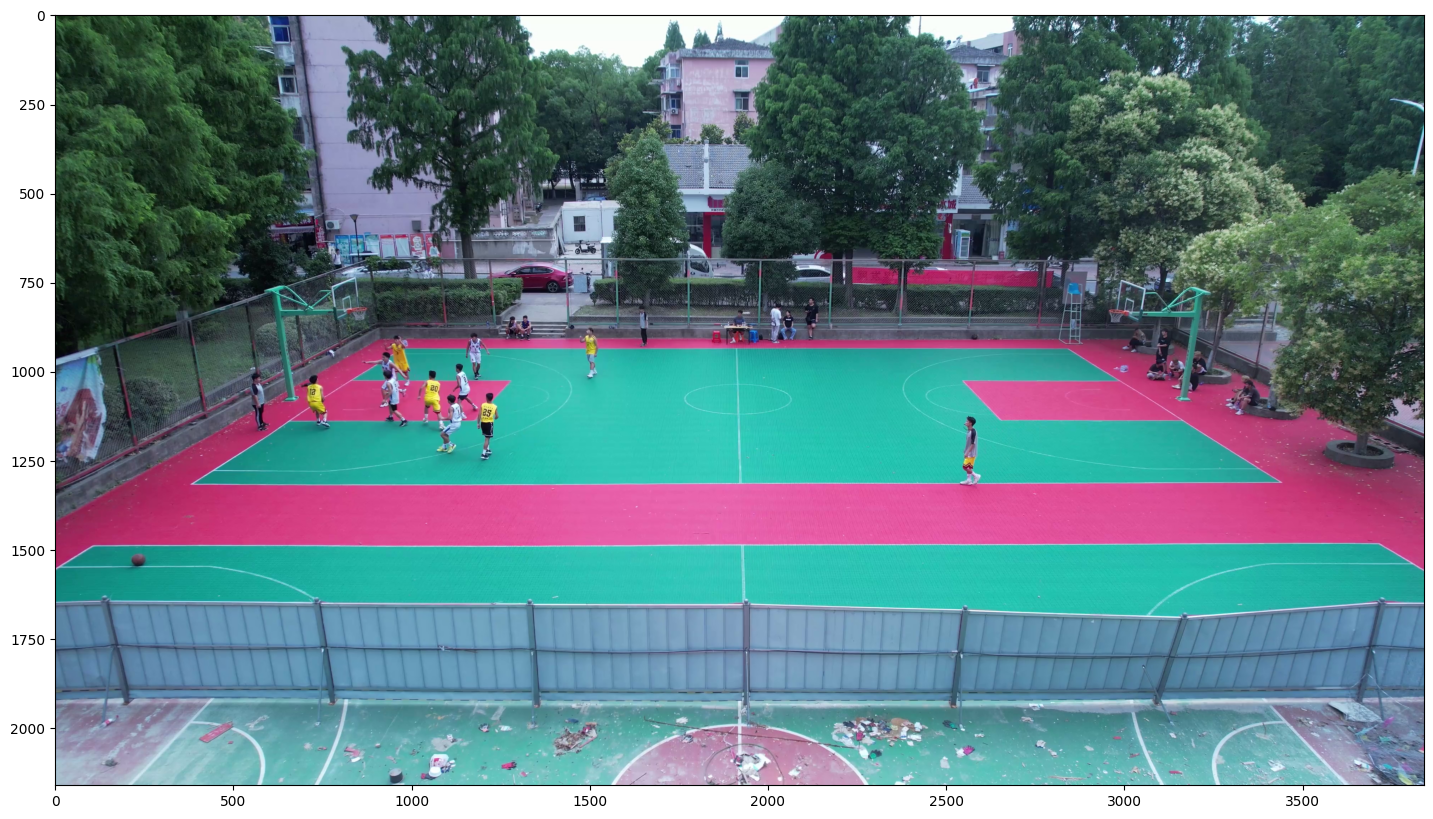

In [2]:
pathlib.Path(config.DATA_PATH).mkdir(parents=True, exist_ok=True)

VIDEO_FILE = 'Q1_side_30-60.mp4'

pickle.dump(VIDEO_FILE, open(f'{config.DATA_PATH}/videopath.p', 'wb'))

# Create folder for images
pathlib.Path('./images/').mkdir(parents=True, exist_ok=True)

# Extract frames
extractFrame(VIDEO_FILE, frameno = (0*60)*15, dest_file = './images/frame_view1.jpg');

In [3]:
SRC = np.float32([
    [973, 932], # Upper left
    [2841, 936], # Upper right
    [383, 1316], # Lower left
    [3440, 1311], # Lower right
    [1915, 1036], # Sign
])

DST = np.float32([
    [88, 91], # Upper left
    [523, 91], # Upper right
    [87, 333], # Lower left
    [523, 334], # Lower right
    [304, 184], # Sign
])

print ('  "cameraPoints" : [[{}, {}], [{}, {}], [{}, {}], [{}, {}]],'.format(
    int(SRC[0][0]), int(SRC[0][1]),
    int(SRC[1][0]), int(SRC[1][1]),
    int(SRC[2][0]), int(SRC[2][1]),
    int(SRC[3][0]), int(SRC[3][1])
))

print ('  "birdEyePoints" : [[{}, {}], [{}, {}], [{}, {}], [{}, {}]],'.format(
    int(DST[0][0]), int(DST[0][1]),
    int(DST[1][0]), int(DST[1][1]),
    int(DST[2][0]), int(DST[2][1]),
    int(DST[3][0]), int(DST[3][1]),
))




  "cameraPoints" : [[973, 932], [2841, 936], [383, 1316], [3440, 1311]],
  "birdEyePoints" : [[88, 91], [523, 91], [87, 333], [523, 334]],


In [4]:
M = cv2.getPerspectiveTransform(SRC[:4], DST[:4])
Minv = cv2.getPerspectiveTransform(DST[:4], SRC[:4])

[973. 932.] -> [88. 91.]
[2841.  936.] -> [523.  91.]
[ 383. 1316.] -> [ 87. 333.]
[3440. 1311.] -> [523. 334.]
[1915. 1036.] -> [303.70837 181.95485]


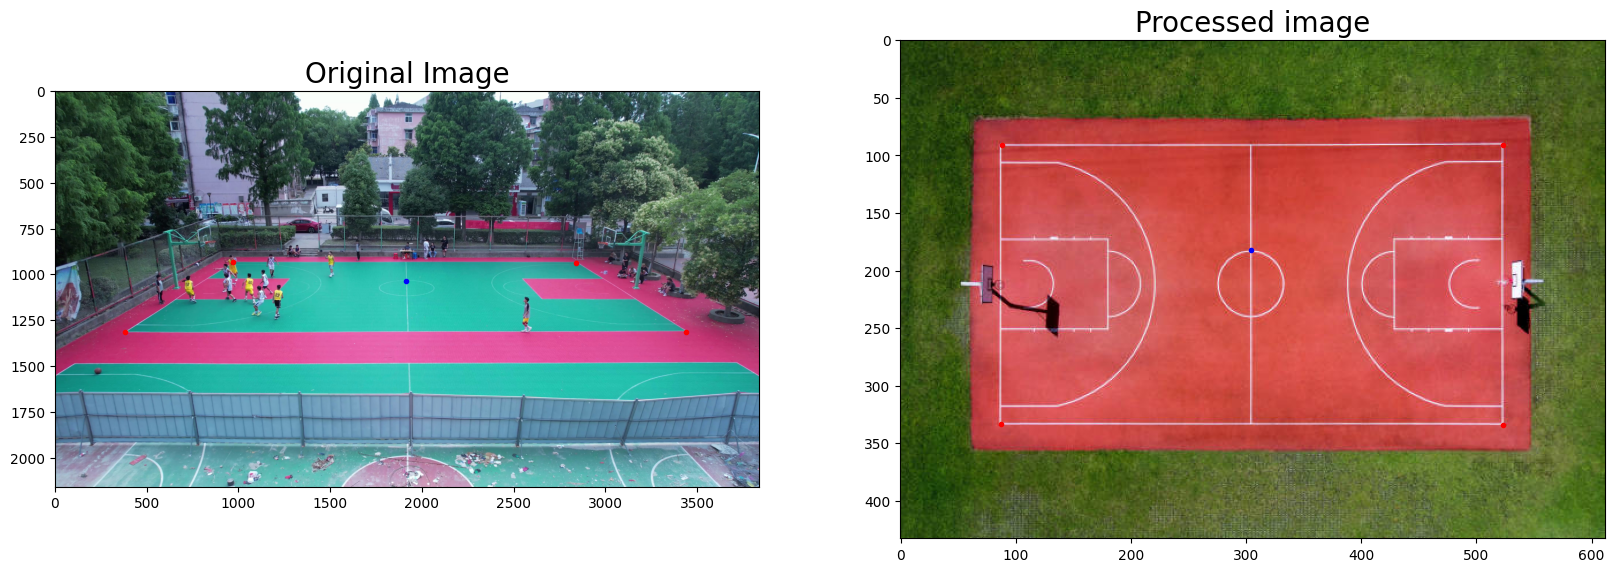

In [5]:
map_file = 'images/Sky View.jpg'
ret = displayPoints(SRC, M, 'images/frame_view1.jpg', map_file)

[88. 91.] -> [973. 932.]
[523.  91.] -> [2841.  936.]
[ 87. 333.] -> [ 383. 1316.]
[523. 334.] -> [3440. 1311.]
[304. 184.] -> [1916.6055 1038.6951]


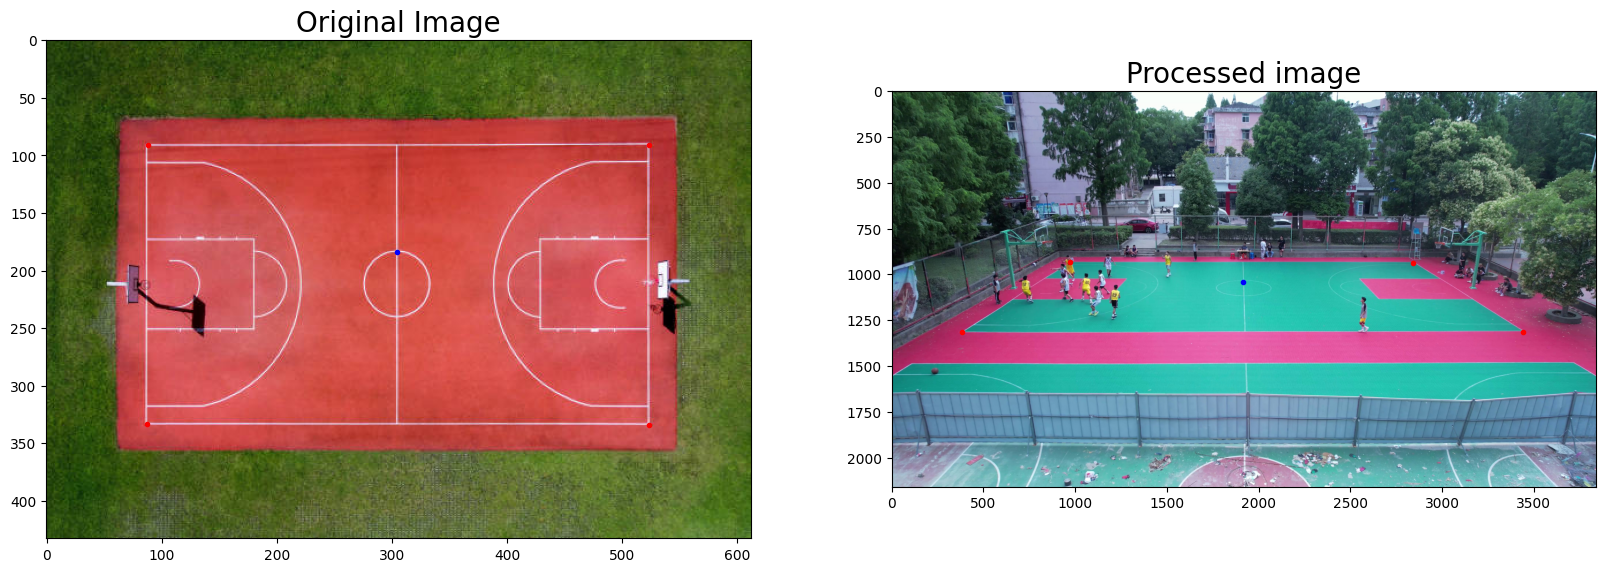

In [6]:
ret = displayPoints(DST, Minv, map_file,  'images/frame_view1.jpg')

✅ Perspective transform matrices generated successfully.
✅ Lanes mask loaded: images/mask_org.png


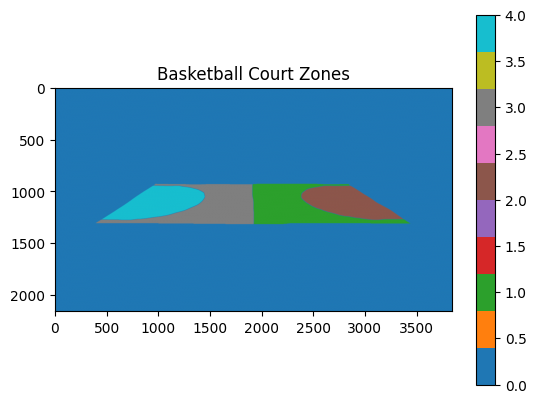

Zone mask values: (array([0, 1, 2, 3, 4]), array([7371773,  271805,  187590,  271359,  191873]))
✅ Zone mask parameters correct!
Zone distribution: {0: 7371773, 1: 271805, 2: 187590, 3: 271359, 4: 191873}


In [7]:
MASK_ORG_PATH = './images/mask_org.png'

from cav.parameters import Parameters
params = Parameters()
params.generateParameters('./params.json')

# Load and verify the zone mask
mask_img = np.array(Image.open(MASK_ORG_PATH).convert('RGB'))
zone_mask = np.zeros(mask_img.shape[:2], dtype=int)

# Use the same color mapping as before
color_to_id = {
    (0, 0, 0): 0, (0, 255, 2): 1, (255, 236, 0): 2,
    (255, 0, 40): 3, (240, 0, 255): 4
}
tol = 10

for color, idx in color_to_id.items():
    matches = np.all(np.abs(mask_img - np.array(color)) <= tol, axis=2)
    zone_mask[matches] = idx

plt.imshow(zone_mask, cmap='tab10')
plt.colorbar()
plt.title('Basketball Court Zones')
plt.show()

unique = np.unique(zone_mask, return_counts=True)
print("Zone mask values:", unique)

# Verify against expected zones
expected_zones = [0, 1, 2, 3, 4]
if sorted(unique[0]) == expected_zones:
    print('✅ Zone mask parameters correct!')
    print(f'Zone distribution: {dict(zip(unique[0], unique[1]))}')
else:
    print(f'❌ Zone mismatch! Expected {expected_zones}, got {sorted(unique[0])}')

In [8]:
import numpy as np

def get_zone_occupancy(df, player_id, zone_id):
    """
    Calculate how long a player spent in a specific zone
    """
    player_data = df[df.playerId == player_id]
    zone_frames = player_data[player_data.zone == zone_id]
    return len(zone_frames) / fps  # Return time in seconds

def detect_zone_transitions(df, player_id, from_zones, to_zones):
    """
    Detect when a player moves between specified zones
    """
    player_data = df[df.playerId == player_id].sort_values('frame')
    transitions = []
    
    for i in range(1, len(player_data)):
        prev_zone = player_data.iloc[i-1]['zone']
        curr_zone = player_data.iloc[i]['zone']
        
        if prev_zone in from_zones and curr_zone in to_zones:
            transitions.append((player_data.iloc[i-1]['frame'], player_data.iloc[i]['frame']))
    
    return transitions

def calculate_zone_speeds(df, player_id, zones):
    """
    Calculate average speed of a player in specific zones
    """
    player_data = df[df.playerId == player_id]
    zone_data = player_data[player_data.zone.isin(zones)]
    
    if len(zone_data) < 2:
        return 0
    
    # Calculate speed based on position changes (you'd need to implement this)
    # This is a placeholder - you'd use your birdEye coordinates and timestamps
    return len(zone_data)  # Placeholder

In [9]:
unique[0][1:]

array([1, 2, 3, 4])

In [10]:
img = cv2.imread('./images/frame_view1.jpg')
skyview = cv2.imread('./images/Sky View.jpg')

jsonfile = '''{{
  "videoShape" : [{}, {}],
  "birdEyeViewShape" : [{}, {}],

  "cameraPoints" : [[{}, {}], [{}, {}], [{}, {}], [{}, {}]],
  "birdEyePoints" : [[{}, {}], [{}, {}], [{}, {}], [{}, {}]],

  "lanes_mask" : "images/mask_org.png"
}}'''.format(
    img.shape[1], img.shape[0],  # videoShape
    skyview.shape[1], skyview.shape[0],  # birdEyeViewShape
    
    int(SRC[0][0]), int(SRC[0][1]),  # cameraPoints
    int(SRC[1][0]), int(SRC[1][1]),
    int(SRC[2][0]), int(SRC[2][1]),
    int(SRC[3][0]), int(SRC[3][1]),
    
    int(DST[0][0]), int(DST[0][1]),  # birdEyePoints
    int(DST[1][0]), int(DST[1][1]),
    int(DST[2][0]), int(DST[2][1]),
    int(DST[3][0]), int(DST[3][1])
)

with open('params.json', 'w') as f:
    for line in jsonfile.split('\n'):
        print(line)
        f.write(line + '\n')

print("✅ params.json created successfully for HoopStats")

{
  "videoShape" : [3840, 2160],
  "birdEyeViewShape" : [612, 433],

  "cameraPoints" : [[973, 932], [2841, 936], [383, 1316], [3440, 1311]],
  "birdEyePoints" : [[88, 91], [523, 91], [87, 333], [523, 334]],

  "lanes_mask" : "images/mask_org.png"
}
✅ params.json created successfully for HoopStats
